This notebook contains experiment for measuring conditional entropy and function that removes all P_id duplicated from the message-based features dataset

In [23]:
import numpy as np
from scipy.stats import pearsonr
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [ ]:


def create_unique_pid_csv(
    input_path: str = "../data/processed/datasets/dataset_message_1to5.csv"
) -> str:

    input_file = Path(input_path)

    if not input_file.exists():
        raise FileNotFoundError(f"Input file not found: {input_file}")

    output_file = input_file.with_name(f"{input_file.stem}_unique_pid.csv")

    df = pd.read_csv(input_file)

    if "P_id" not in df.columns:
        raise ValueError("Column 'P_id' not found in the input CSV.")

    df_unique = df.drop_duplicates(subset="P_id", keep="first")

    df_unique.to_csv(output_file, index=False)

    print(f"Saved deduplicated file to: {output_file}")
    print(f"Original rows: {len(df)}")
    print(f"Rows after removing duplicate P_id values: {len(df_unique)}")
    print(f"Removed rows: {len(df) - len(df_unique)}")

    return str(output_file)
create_unique_pid_csv()

Saved deduplicated file to: ../data/processed/datasets/dataset_message_1to5_unique_pid.csv
Original rows: 137610
Rows after removing duplicate P_id values: 75440
Removed rows: 62170


'../data/processed/datasets/dataset_message_1to5_unique_pid.csv'

Entropy analysis

In [ ]:


def binary_entropy(p):

    p = np.asarray(p, dtype=float)

    out = np.zeros_like(p, dtype=float)
    mask = (p > 0) & (p < 1)

    out[mask] = -(p[mask] * np.log2(p[mask]) +
                  (1 - p[mask]) * np.log2(1 - p[mask]))
    return out


def measure_conditional_entropy(df):

    data = df.copy()

    # group only by P_id
    counts = (
        data.groupby(["P_id", "label"], dropna=False)
        .size()
        .unstack(fill_value=0)
    )
    counts[0] = counts.get(0, 0)
    counts[1] = counts.get(1, 0)

    n0 = counts[0].to_numpy()
    n1 = counts[1].to_numpy()
    n = n0 + n1

    # p(y=1 | P_id)
    p1 = np.divide(n1, n, out=np.zeros_like(n1, dtype=float), where=n > 0)

    # entropy for each P_id group
    group_entropy = binary_entropy(p1)

    # weight by group frequency P(P_id) = n / N
    N = n.sum()
    conditional_entropy = np.sum((n / N) * group_entropy) if N > 0 else np.nan

    return {
        "conditional_entropy_bits": float(conditional_entropy),
    }

In [20]:
def evaluate_entropy_by_hashtag(df):
    results = {}
    for tag in df["hashtag"].dropna().unique():
        df_tag = df[df["hashtag"] == tag]
        results[tag] = measure_conditional_entropy(df_tag)
    return results

df = pd.read_csv("../data/processed/datasets/dataset_message_1to1.csv")
results_by_tag = evaluate_entropy_by_hashtag(df)
print(results_by_tag)

{'Trump': {'conditional_entropy_bits': 0.19747888797537122}, 'ICE': {'conditional_entropy_bits': 0.20751819126160115}, 'Gaza': {'conditional_entropy_bits': 0.19051692781513788}, 'Pokemon': {'conditional_entropy_bits': 0.32696755887409434}, 'AI': {'conditional_entropy_bits': 0.10092360230490913}, 'Booksky': {'conditional_entropy_bits': 0.2231302512872045}, 'BlackHistoryMonth': {'conditional_entropy_bits': 0.30141275525808064}, 'TheTraitors': {'conditional_entropy_bits': 0.10446985878189419}, 'Anime': {'conditional_entropy_bits': 0.19091593795703593}, 'Superbowl': {'conditional_entropy_bits': 0.17253417585137382}}


Pearson r = -0.200, p = 0.580


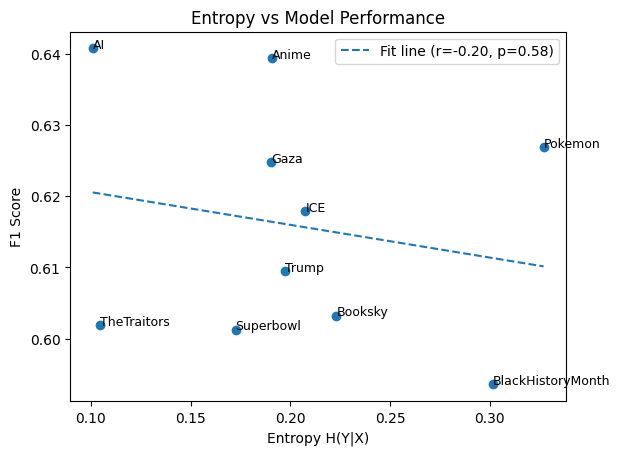

In [ ]:


entropy = {
    key: value["conditional_entropy_bits"]
    for key, value in results_by_tag.items()
}

f1 = {
    "Trump": 0.6094410180074721,
    "ICE": 0.61787678110531,
    "Gaza": 0.6247813609988312,
    "Pokemon": 0.6268420276294292,
    "AI": 0.6407213891510145,
    "Booksky": 0.6032297723972981,
    "BlackHistoryMonth": 0.5935803933735072,
    "TheTraitors": 0.6018781305740882,
    "Anime": 0.6393279546278565,
    "Superbowl": 0.6012758289602403,
}

tags = list(entropy.keys())
x = np.array([entropy[t] for t in tags])
y = np.array([f1[t] for t in tags])

r, p = pearsonr(x, y)
print(f"Pearson r = {r:.3f}, p = {p:.3f}")

plt.figure()
plt.scatter(x, y)

for i, tag in enumerate(tags):
    plt.text(x[i], y[i], tag, fontsize=9)

m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

plt.plot(x_line, y_line, linestyle='--', label=f"Fit line (r={r:.2f}, p={p:.2f})")

plt.xlabel("Entropy H(Y|X)")
plt.ylabel("F1 Score")
plt.title("Entropy vs Model Performance")
plt.legend()
plt.show()

The permutation test to calculate p-value

In [ ]:


# x = entropy values
# y = mean F1 values

r_obs, _ = pearsonr(x, y)

n_perm = 100000
count = 0
rng = np.random.default_rng(42)

for _ in range(n_perm):
    y_perm = rng.permutation(y)
    r_perm, _ = pearsonr(x, y_perm)
    if abs(r_perm) >= abs(r_obs):   # two-sided test
        count += 1

p_mc = (count + 1) / (n_perm + 1)

print("Observed r:", r_obs)
print("Monte Carlo p-value:", p_mc)

Observed r: -0.19963823259004831
Monte Carlo p-value: 0.5773942260577394
